Processed: data_leftaxlebox_M0_G0_LA3_RA0_20Hz_+10kN.csv
Processed: data_leftaxlebox_M0_G0_LA3_RA0_20Hz_-10kN.csv
Processed: data_leftaxlebox_M0_G0_LA3_RA0_20Hz_0kN.csv
Processed: data_leftaxlebox_M0_G0_LA3_RA0_40Hz_+10kN.csv
Processed: data_leftaxlebox_M0_G0_LA3_RA0_40Hz_-10kN.csv
Processed: data_leftaxlebox_M0_G0_LA3_RA0_40Hz_0kN.csv
Processed: data_leftaxlebox_M0_G0_LA3_RA0_60Hz_+10kN.csv
Processed: data_leftaxlebox_M0_G0_LA3_RA0_60Hz_-10kN.csv
Processed: data_leftaxlebox_M0_G0_LA3_RA0_60Hz_0kN.csv


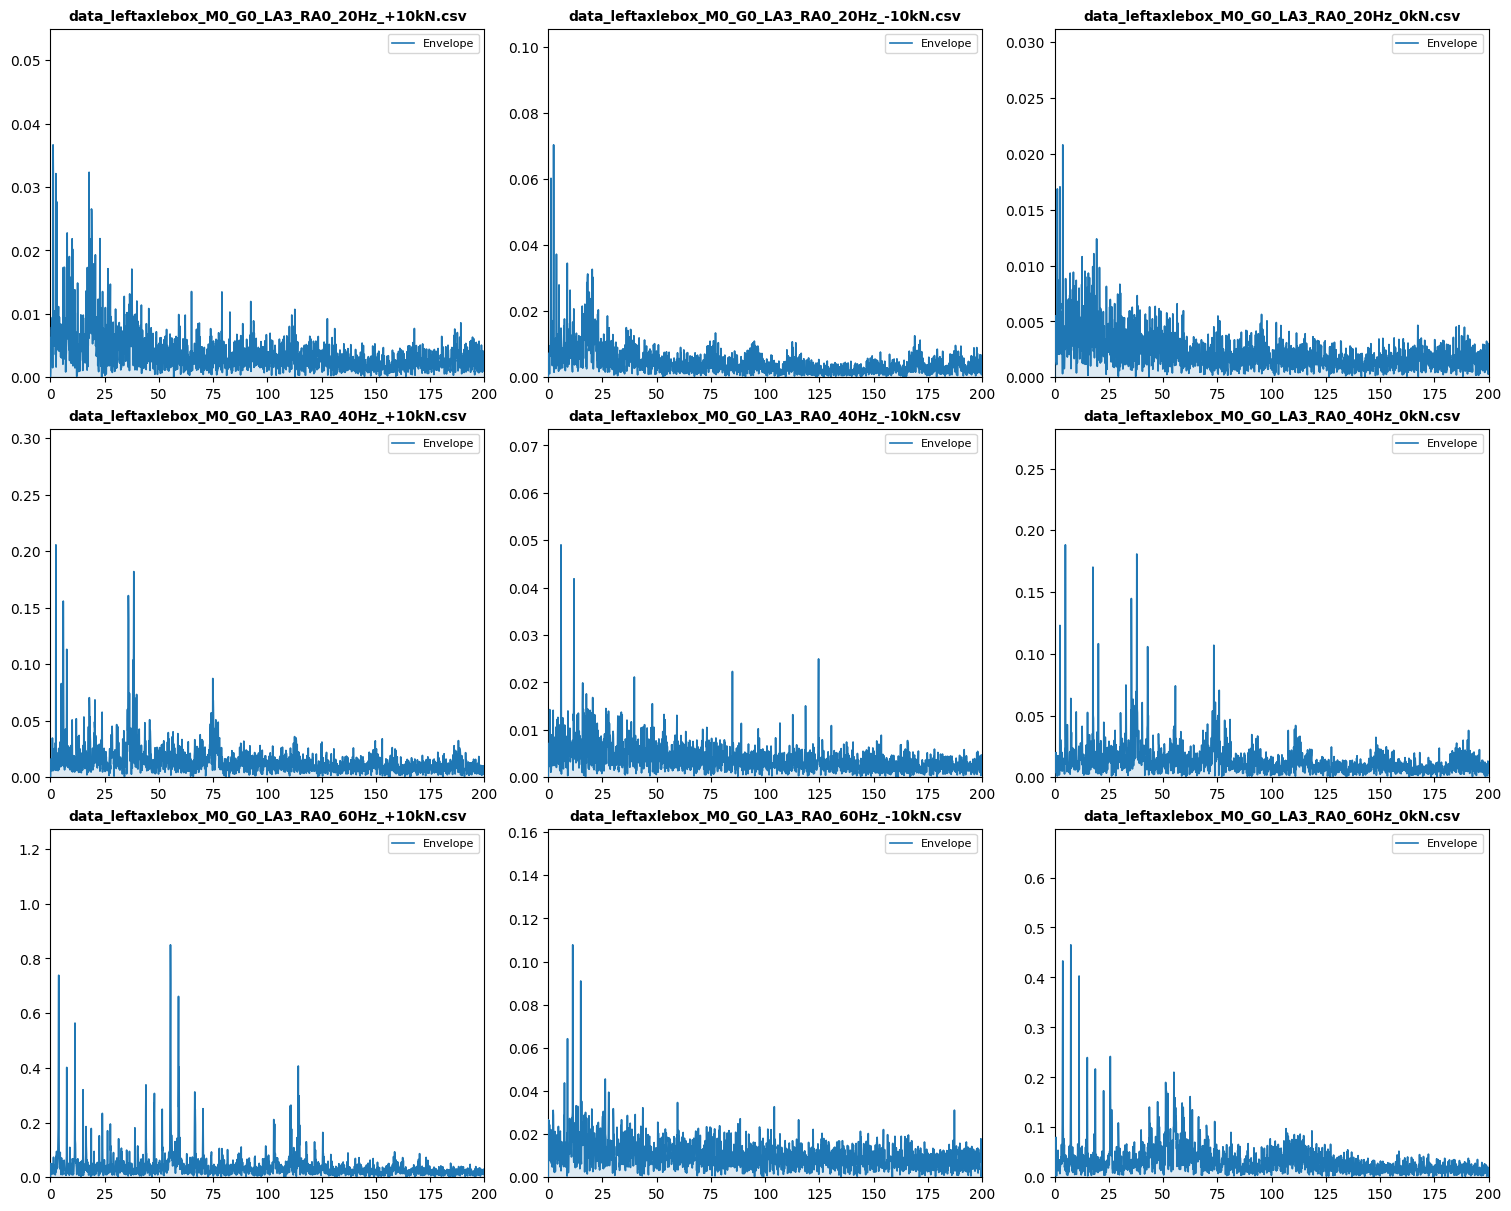

Processed: data_leftaxlebox_M0_G0_LA1_RA0_20Hz_+10kN.csv
Processed: data_leftaxlebox_M0_G0_LA1_RA0_20Hz_-10kN.csv
Processed: data_leftaxlebox_M0_G0_LA1_RA0_20Hz_0kN.csv
Processed: data_leftaxlebox_M0_G0_LA1_RA0_40Hz_+10kN.csv
Processed: data_leftaxlebox_M0_G0_LA1_RA0_40Hz_-10kN.csv
Processed: data_leftaxlebox_M0_G0_LA1_RA0_40Hz_0kN.csv
Processed: data_leftaxlebox_M0_G0_LA1_RA0_60Hz_+10kN.csv
Processed: data_leftaxlebox_M0_G0_LA1_RA0_60Hz_-10kN.csv
Processed: data_leftaxlebox_M0_G0_LA1_RA0_60Hz_0kN.csv


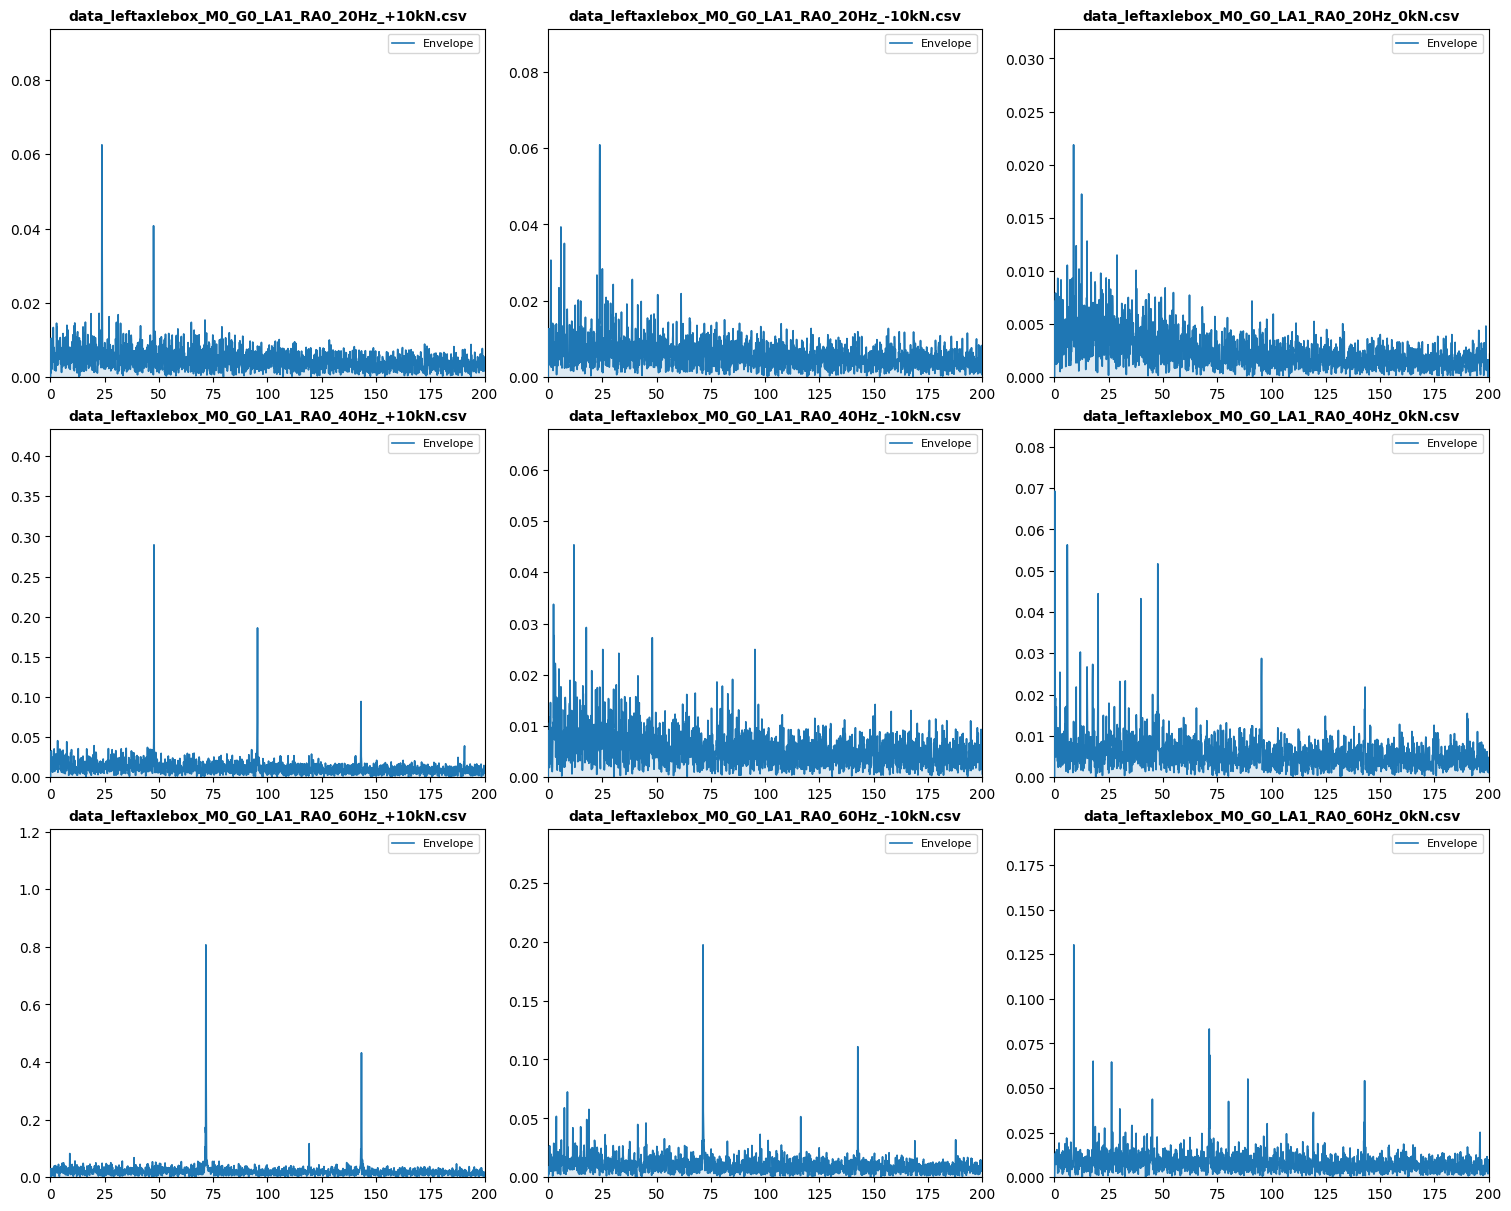

Processed: data_leftaxlebox_M0_G0_LA2_RA0_20Hz_+10kN.csv
Processed: data_leftaxlebox_M0_G0_LA2_RA0_20Hz_-10kN.csv
Processed: data_leftaxlebox_M0_G0_LA2_RA0_20Hz_0kN.csv
Processed: data_leftaxlebox_M0_G0_LA2_RA0_40Hz_+10kN.csv
Processed: data_leftaxlebox_M0_G0_LA2_RA0_40Hz_-10kN.csv
Processed: data_leftaxlebox_M0_G0_LA2_RA0_40Hz_0kN.csv
Processed: data_leftaxlebox_M0_G0_LA2_RA0_60Hz_+10kN.csv
Processed: data_leftaxlebox_M0_G0_LA2_RA0_60Hz_-10kN.csv
Processed: data_leftaxlebox_M0_G0_LA2_RA0_60Hz_0kN.csv


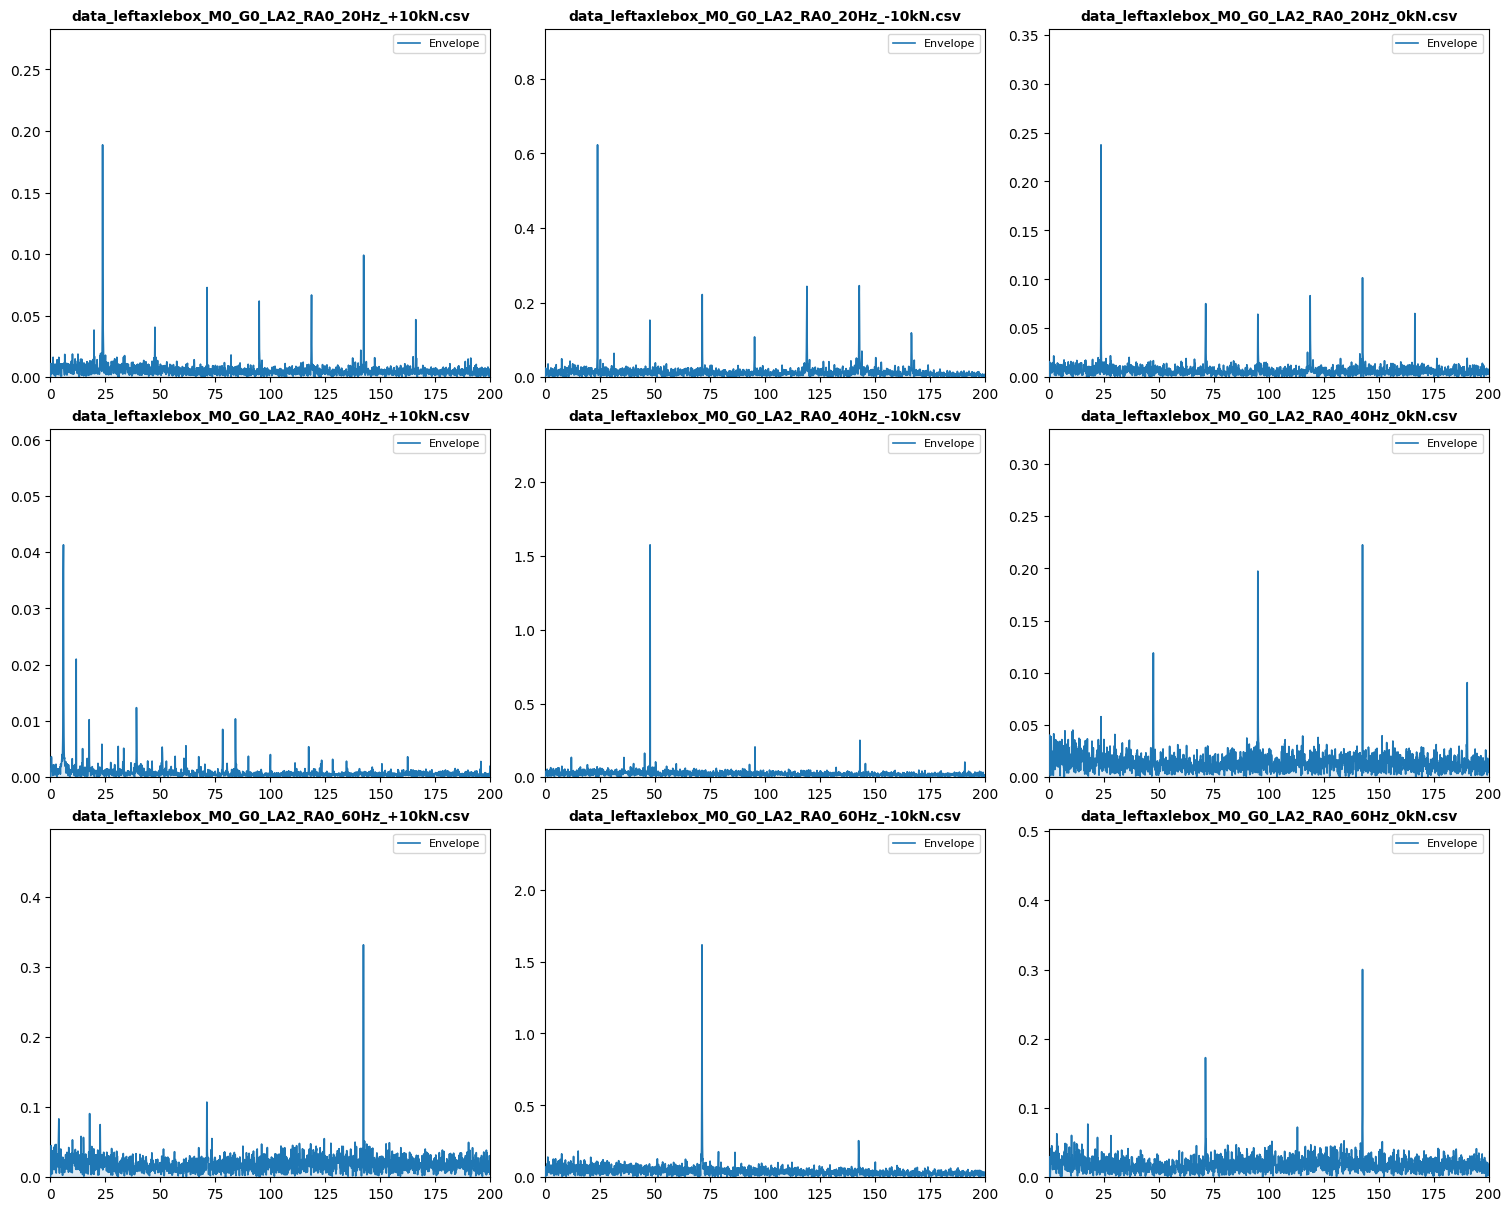

Processed: data_leftaxlebox_M0_G0_LA2+LA3_RA0_20Hz_+10kN.csv
Processed: data_leftaxlebox_M0_G0_LA2+LA3_RA0_20Hz_-10kN.csv
Processed: data_leftaxlebox_M0_G0_LA2+LA3_RA0_20Hz_0kN.csv
Processed: data_leftaxlebox_M0_G0_LA2+LA3_RA0_40Hz_+10kN.csv
Processed: data_leftaxlebox_M0_G0_LA2+LA3_RA0_40Hz_-10kN.csv
Processed: data_leftaxlebox_M0_G0_LA2+LA3_RA0_40Hz_0kN.csv
Processed: data_leftaxlebox_M0_G0_LA2+LA3_RA0_60Hz_+10kN.csv
Processed: data_leftaxlebox_M0_G0_LA2+LA3_RA0_60Hz_-10kN.csv
Processed: data_leftaxlebox_M0_G0_LA2+LA3_RA0_60Hz_0kN.csv


D:\anaconda\envs\pytorch\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21253 (\N{CJK UNIFIED IDEOGRAPH-5305}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\envs\pytorch\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32476 (\N{CJK UNIFIED IDEOGRAPH-7EDC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\envs\pytorch\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24133 (\N{CJK UNIFIED IDEOGRAPH-5E45}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\envs\pytorch\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


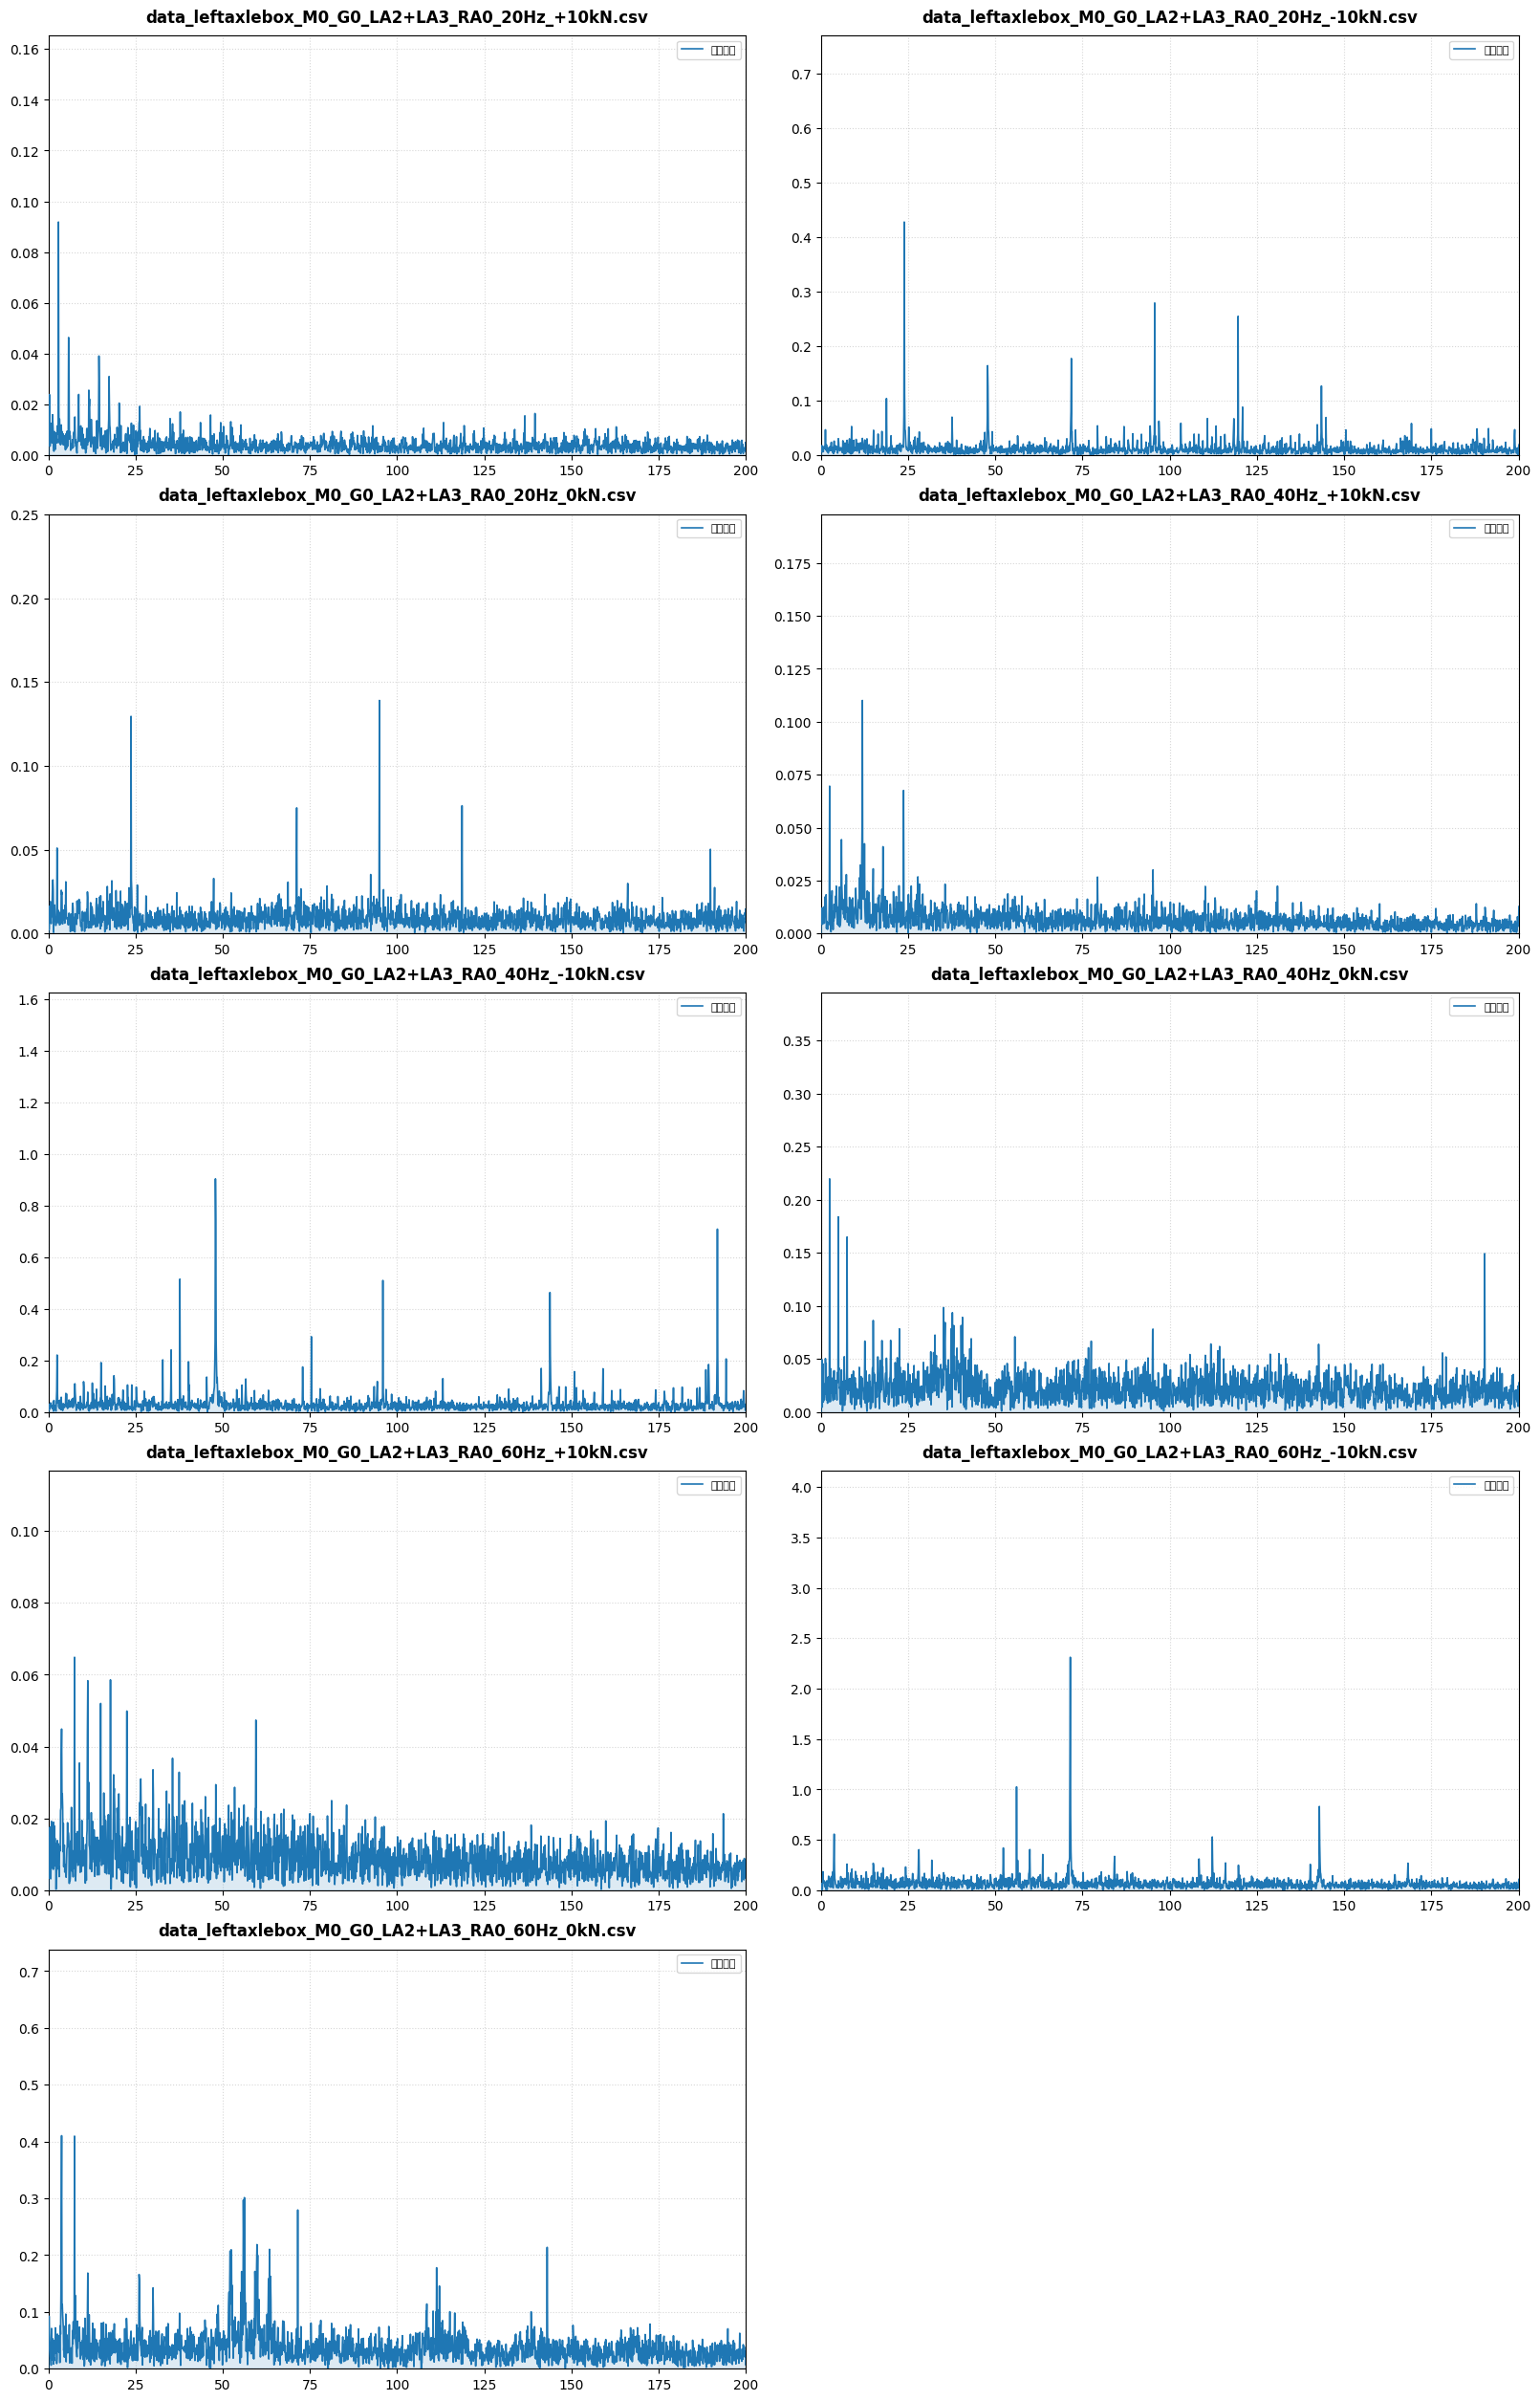

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import fftpack


class BearingAnalyzer:
    def __init__(self, fs=25600, xlim=100):
        """
        初始化分析器
        :param fs: 采样频率
        :param xlim: 频谱图显示的频率上限
        """
        self.fs = fs
        self.xlim = xlim
        # 轴承几何常数 (根据 BJTU 提供的 107/16 传动比计算)
        self.ratio = 107 / 16
        self.coeffs = {
            'BPFO': 8.071,  # 外圈故障系数
            'BPFI': 10.929,  # 内圈故障系数
            'BSF': 3.164  # 滚动体故障系数
        }

    def get_envelope(self, data, max_points=640000):
        """核心算法：提取包络谱"""
        # 截取信号并去直流
        xt = data[:max_points]
        ht = fftpack.hilbert(xt)
        at = np.sqrt(xt ** 2 + ht ** 2)
        at = at - np.mean(at)

        # FFT 变换
        n = len(at)
        am = np.abs(np.fft.fft(at))
        am = (am / n) * 2

        # 取正频率部分
        half_n = n // 2
        freq = np.fft.fftfreq(n, d=1 / self.fs)[:half_n]
        amp = am[:half_n]
        return freq, amp

    def plot_diagnostic(self, ax, freq, amp, motor_f, title, fault_type='BSF'):
        """绘图与理论频率标注"""
        fr = motor_f / self.ratio  # 计算轴转频

        # 绘制包络谱
        ax.plot(freq, amp, color='#1f77b4', lw=1.2, label='Envelope', zorder=3)
        ax.fill_between(freq, amp, color='#1f77b4', alpha=0.15)

        # # 标注故障特征频率 (1倍频与2倍频)
        # if fault_type in self.coeffs:
        #     f_fault = fr * self.coeffs[fault_type]
        #     label_name = f"{fault_type}: {f_fault:.2f}Hz"
        #     ax.axvline(f_fault, color='#d62728', ls='--', lw=1.5, label=label_name, zorder=4)
        #     ax.axvline(f_fault * 2, color='#d62728', ls=':', lw=1, alpha=0.6, zorder=4)

        # # 标注转频
        # ax.axvline(fr, color='#7f7f7f', ls='--', alpha=0.5, label=f'fr: {fr:.2f}Hz')

        # 细节优化
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xlim(0, self.xlim)
        # 自动调整Y轴刻度 (避开1Hz以内的低频干扰)
        valid_idx = freq > 1
        if any(valid_idx):
            ax.set_ylim(0, np.max(amp[valid_idx]) * 1.5)
        ax.legend(loc='upper right', fontsize=8)

    def process_folder(self, folder_path, fault_type='BSF'):
        """批量处理文件夹内的所有 CSV 文件"""
        files = sorted([f for f in os.listdir(folder_path) if f.endswith('.csv')])
        cols = 3
        rows = (len(files) + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows), constrained_layout=True)
        axes = axes.flatten()
        for i, file_name in enumerate(files):
            # 1. 自动从文件名解析频率 (假设格式为 ..._40Hz_...)
            motor_f = float(file_name.split('Hz')[0].split('_')[-1])
            df = pd.read_csv(os.path.join(folder_path, file_name))
            data = df.iloc[:, 0].values
            # 3. 计算与绘图
            f, a = self.get_envelope(data)
            self.plot_diagnostic(axes[i], f, a, motor_f, file_name, fault_type)
            print(f"Processed: {file_name}")

        # 隐藏多余子图
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.show()


# --- 使用示例 ---
analyzer = BearingAnalyzer(fs=64000, xlim=200)
analyzer.process_folder('../数据集/BJTU/滚动体', fault_type='BSF')
analyzer = BearingAnalyzer(fs=64000, xlim=200)
analyzer.process_folder('../数据集/BJTU/内圈', fault_type='BPFI')
analyzer.process_folder('../数据集/BJTU/外圈', fault_type='BPFI')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import fftpack


class BearingAnalyzer:
    def __init__(self, fs, xlim=100):
        self.fs = fs
        self.xlim = xlim
        self.ratio = 107 / 16
        # 定义故障特征系数与视觉样式
        self.fault_config = {
            'BPFO': {'coeff': 8.071, 'color': '#d62728', 'ls': '--', 'label': '外圈 BPFO'},
            'BPFI': {'coeff': 10.929, 'color': '#ff7f0e', 'ls': ':', 'label': '内圈 BPFI'},
            'BSF': {'coeff': 3.164, 'color': '#2ca02c', 'ls': '-.', 'label': '滚动体 BSF'}
        }

    def get_envelope(self, data, max_points=640000):
        """提取包络谱"""
        xt = data[:max_points]
        ht = fftpack.hilbert(xt)
        at = np.sqrt(xt ** 2 + ht ** 2)
        at = at - np.mean(at)

        n = len(at)
        am = np.abs(np.fft.fft(at))
        am = (am / n) * 2

        half_n = n // 2
        freq = np.fft.fftfreq(n, d=1 / self.fs)[:half_n]
        amp = am[:half_n]
        return freq, amp

    def plot_diagnostic(self, ax, freq, amp, motor_f, title, fault_types=['BPFO', 'BSF']):
        """
        绘制诊断图，支持多故障同时标记
        """
        fr = motor_f / self.ratio

        # 1. 绘制包络曲线
        ax.plot(freq, amp, color='#1f77b4', lw=1.2, label='包络幅值', zorder=3)
        ax.fill_between(freq, amp, color='#1f77b4', alpha=0.15, zorder=2)

        # # 2. 循环标注多种故障类型
        # for ft in fault_types:
        #     if ft in self.fault_config:
        #         conf = self.fault_config[ft]
        #         f_val = fr * conf['coeff']
        #         # 标注 1 倍频
        #         ax.axvline(f_val, color=conf['color'], linestyle=conf['ls'],
        #                    lw=1.8, label=f"{conf['label']} ({f_val:.2f}Hz)", zorder=4)
        #         # 标注 2 倍频 (淡化处理)
        #         ax.axvline(f_val * 2, color=conf['color'], linestyle=conf['ls'],
        #                    lw=1.2, alpha=0.5, zorder=4)

        # # 3. 标注车轴转频
        # ax.axvline(fr, color='#7f7f7f', ls='--', alpha=0.6, label=f'车轴转频 fr ({fr:.2f}Hz)', zorder=1)

        # 4. 细节美化
        ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
        ax.set_xlim(0, self.xlim)
        ax.grid(True, linestyle=':', alpha=0.5)

        # 动态调整 Y 轴 (避开低频噪声)
        valid_idx = freq > 1
        if any(valid_idx):
            ax.set_ylim(0, np.max(amp[valid_idx]) * 1.8)

        ax.legend(loc='upper right', fontsize=8, frameon=True, shadow=False)

    def process_folder(self, folder_path, fault_types=['BPFO', 'BSF']):
        """批量处理文件夹并绘图"""
        files = sorted([f for f in os.listdir(folder_path) if f.endswith('.csv')])
        if not files:
            print("Error: No CSV files found.")
            return

        cols = 2  # 复合故障标记信息较多，建议改为 2 列布局更清晰
        rows = (len(files) + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows), constrained_layout=True)

        # 处理只有一个文件的情况
        if len(files) == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        for i, file_name in enumerate(files):
            # 自动解析频率
            try:
                motor_f = float(file_name.split('Hz')[0].split('_')[-1])
            except:
                motor_f = 40.0

            # 读取数据
            df = pd.read_csv(os.path.join(folder_path, file_name))
            data = df.iloc[:, 0].values  # 默认取第一列

            # 分析与绘图
            f, a = self.get_envelope(data)
            self.plot_diagnostic(axes[i], f, a, motor_f, file_name, fault_types)
            print(f"Processed: {file_name}")

        # 隐藏空白子图
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.show()


# --- 执行脚本 ---
# 根据你之前提到的 fs=64000
analyzer = BearingAnalyzer(fs=64000, xlim=200)
# 同时分析 BPFO (外圈) 和 BSF (滚动体)
analyzer.process_folder('../数据集/BJTU/外圈加滚动体', fault_types=['BPFO', 'BSF'])